# Metadata Exploration 

In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import time
import sys
import matplotlib.pyplot as plt
import math
import os
from itertools import product

from sklearn.cluster import MiniBatchKMeans
import seaborn as sns
import scanpy as sc
from dotenv import load_dotenv
import pickle as pkl
from scipy import stats

load_dotenv()

True

In [2]:
# From SingleCell Neighborhood Analysis
def get_windows(job,n_neighbors):
    start_time,idx,tissue_name,indices = job
    job_start = time.time()

    print ("Starting:", str(idx+1)+'/'+str(len(exps)),': ' + exps[idx])

    tissue = tissue_group.get_group(tissue_name)
    to_fit = tissue.loc[indices][[X,Y]].values

    fit = NearestNeighbors(n_neighbors=n_neighbors).fit(tissue[[X,Y]].values)
    m = fit.kneighbors(to_fit)

    #sort_neighbors
    args = m[0].argsort(axis = 1)
    add = np.arange(m[1].shape[0])*m[1].shape[1]
    sorted_indices = m[1].flatten()[args+add[:,None]]

    neighbors = tissue.index.values[sorted_indices]

    end_time = time.time()

    print ("Finishing:", str(idx+1)+"/"+str(len(exps)),": "+ exps[idx],end_time-job_start,end_time-start_time)
    return neighbors.astype(np.int32)

def get_adata(data, list_keep_obs=None, index_nam = 'tissue_index'):

    if list_keep_obs is None:
        list_keep_obs = ['first_index', 'x', 'y', 'tissue', 'donor', 'region', 'OLFM4', 'FAP',
       'CD25', 'CollIV', 'CK7', 'Xcorr', 'Ycorr', 'unique_region',
       'neigh_name', 'neigh_sub1', 'Preservation_method', 'Tissue_location',
       'array', 'Cell Type', 'Cell Type em', 'Cell subtype', 'machine',
       'MUC6', index_nam]
    data.reset_index(inplace=True)
    data.rename(columns={'index':index_nam}, inplace=True)

    #Prepare for making into anndata format so that obs and data are separate
    data_sc = data.drop(columns = list_keep_obs) #USER INPUT

    #Convert to anndata format
    adata = sc.AnnData(data_sc)
    adata.obs = data[list_keep_obs]
    m_list = adata.var.index.to_list()

    return adata, m_list


def adata_to_dataframe(adata):
    df_var = adata.to_df()
    df_obs = adata.obs
    df = pd.concat([df_var,df_obs], axis=1)
    return df


def sc_heat(data, cell_type, cell_col, vmax=5):
    data_subset = data[data.obs[cell_col] == cell_type]
    sc.pl.heatmap(data_subset, var_names=data.var_names, vmax=vmax, figsize=(20,10), show_gene_labels=True)


def swarm_box(data, grouping, replicate, sub_col, sub_list, per_cat, norm=True,\
              figure_sizing=(10,5), save_name=None, h_order=None):

    plt.style.use(['default'])
    #GENERAL GRAPH SETTINGs
    #font size of graph
    SMALL_SIZE = 14
    MEDIUM_SIZE = 16
    BIGGER_SIZE = 18

    #Settings for graph
    plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
    plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
    plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
    plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
    plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
    plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
    plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

    #Find Percentage of cell type
    test= data.copy()
    sub_list1 = sub_list.copy()

    if norm==True:
        test1 = test.loc[test[sub_col].isin(sub_list1)]
        immune_list = list(test1[per_cat].unique())
    else:
        test1=test.copy()
        immune_list = list(test.loc[test[sub_col].isin(sub_list1)][per_cat].unique())

    test1[per_cat] = test1[per_cat].astype('category')
    test_freq = test1.groupby([grouping,replicate]).apply(lambda x: x[per_cat].value_counts(normalize = True,sort = False)*100)
    test_freq.columns = test_freq.columns.astype(str)
    test_freq.reset_index(inplace=True)
    immune_list.extend([grouping,replicate])
    test_freq1 = test_freq[immune_list]

    melt_per_plot = pd.melt(test_freq1, id_vars=[grouping,replicate,])#,value_vars=immune_list)
    melt_per_plot.rename(columns={'value': 'percentage'}, inplace=True)

    #Order by average
    plot_order = melt_per_plot.groupby(per_cat).mean().reset_index().sort_values(by='percentage')[per_cat].to_list()

    if h_order is None:
        h_order = list(melt_per_plot[grouping].unique())

    #swarmplot to compare clustering
    plt.figure(figsize=figure_sizing)
    ax = sns.boxplot(data = melt_per_plot, x=per_cat,  y='percentage', hue = grouping, dodge=True, order=plot_order,\
                     hue_order=h_order)
    ax = sns.swarmplot(data = melt_per_plot, x=per_cat, y='percentage', hue = grouping, dodge=True, order=plot_order,\
                      hue_order=h_order, edgecolor='black',linewidth=1)
    for patch in ax.artists:
        r, g, b, a = patch.get_facecolor()
        patch.set_facecolor((r, g, b, .3))
    #ax.set_yscale(\log\)
    plt.xlabel('')
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles[:len(melt_per_plot[grouping].unique())], labels[:len(melt_per_plot[grouping].unique())],\
               bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.,frameon=False)
    plt.xticks(rotation=90)
    sns.despine(trim=True)
    if save_name:
        plt.savefig(save_path+save_name+'_swarm_boxplot.png', format='png', dpi=300, transparent=True, bbox_inches='tight')

    return melt_per_plot

def stacked_bar_plot(data, per_cat, grouping, cell_list, norm=True, save_name=None,\
              col_order=None, sub_col=None, name_cat = 'Cell Type',fig_sizing=(8,4), pal_color=None):

    #Find Percentage of cell type
    cell_list_1 = cell_list.copy()
    test= data.copy()
    if norm==True:
        if sub_col is None:
            test1 = test.loc[test[per_cat].isin(cell_list_1)]
            sub_cell_list = list(test1[per_cat].unique())
        else:
            test1 = test.loc[test[sub_col].isin(cell_list_1)]
            sub_cell_list = list(test1[per_cat].unique())
    else:
        if sub_col is None:
            test1 = test.copy()
            sub_cell_list = list(test.loc[test[per_cat].isin(cell_list_1)][per_cat].unique())
        else:
            test1 = test.copy()
            sub_cell_list = list(test.loc[test[sub_col].isin(cell_list_1)][per_cat].unique())

    test1[per_cat] = test1[per_cat].astype('category')
    test_freq = test1.groupby(grouping).apply(lambda x: x[per_cat].value_counts(normalize = True,sort = False)*100)
    test_freq.columns = test_freq.columns.astype(str)

    ##### Can subset it here if I do not want normalized per the group
    test_freq.reset_index(inplace=True)
    sub_cell_list.append(grouping)
    test_freq = test_freq[sub_cell_list]
    melt_test = pd.melt(test_freq, id_vars=[grouping])#, value_vars=test_freq.columns)
    melt_test.rename(columns = {per_cat: name_cat, 'value':'percent'},  inplace = True)

    if norm==True:
        if col_order is None:
            bb = melt_test.groupby([grouping, per_cat]).sum().reset_index()
            col_order = bb.loc[bb[per_cat]==bb[per_cat][0]].sort_values(by='percent')[grouping].to_list()
    else:
        if col_order is None:
            col_order = melt_test.groupby(grouping).sum().reset_index().sort_values(by='percent')[grouping].to_list()

    #Set up for plotting
    melt_test_piv = pd.pivot_table(melt_test, columns = [name_cat], index=[grouping], values=['percent'])
    melt_test_piv.columns = melt_test_piv.columns.droplevel(0)
    melt_test_piv.reset_index(inplace=True)
    melt_test_piv.set_index(grouping, inplace=True)
    melt_test_piv = melt_test_piv.reindex(col_order)

    #Get color dictionary
    if pal_color is None:
        cond_list = list(melt_test_piv.columns)
        color_list=list(pal_temp.values())
        pal_color = dict(zip(cond_list, color_list))

    #first subplot
    ax1 = melt_test_piv.plot.bar(alpha = 0.8, linewidth=1, color=[pal_color.get(x) for x in melt_test_piv.columns]\
                                  , figsize =fig_sizing, rot=90,stacked=True, edgecolor='black')
    for line in ax1.lines:
        line.set_color('black')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.set_ylabel('percent')
    #ax1.spines['left'].set_position(('data', 1.0))
    #ax1.set_xticks(np.arange(1,melt_test.day.max()+1,1))
    #ax1.set_ylim([0, int(ceil(max(max(melt_test_piv.sum(axis=1)), max(tm_piv.sum(axis=1)))))])
    plt.xticks(list(range(len(list(melt_test_piv.index)))), list(melt_test_piv.index), rotation=90)
    lgd2 = ax1.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, frameon=False)
    if save_name:
        plt.savefig(save_path+save_name+'.png', format='png',\
                    dpi=300, transparent=True, bbox_inches='tight')

def area_plot(data, per_cat, grouping, cell_list, sub_col, color_dict=None, \
              norm=False, save_name=None, col_order=None, name_cat = 'Cell Type',fig_sizing=(8,4)):
    if col_order is None:
        col_order=list(data[grouping].unique())

    cell_list_1 = cell_list.copy()
    #Find Percentage of cell type
    test= data.copy()
    if norm==True:
        test1 = test.loc[test[sub_col].isin(cell_list_1)]
        immune_list = list(test1[per_cat].unique())
    else:
        test1 = test.copy()
        immune_list = list(test.loc[test[sub_col].isin(cell_list_1)][per_cat].unique())

    test1[per_cat] = test1[per_cat].astype('category')
    test_freq = test1.groupby(grouping).apply(lambda x: x[per_cat].value_counts(normalize = True,sort = False)*100)
    test_freq.columns = test_freq.columns.astype(str)

    ##### Can subset it here if I do not want normalized per the group
    test_freq.reset_index(inplace=True)
    immune_list.append(grouping)
    test_freq = test_freq[immune_list]
    melt_test = pd.melt(test_freq, id_vars=[grouping])#, value_vars=test_freq.columns)
    melt_test.rename(columns = {per_cat: name_cat, 'value':'percent'},  inplace = True)

    #Set up for plotting
    melt_test_piv = pd.pivot_table(melt_test, columns = [name_cat], index=[grouping], values=['percent'])
    melt_test_piv.columns = melt_test_piv.columns.droplevel(0)
    melt_test_piv.reset_index(inplace=True)
    melt_test_piv.set_index(grouping, inplace=True)
    melt_test_piv = melt_test_piv.reindex(col_order)
    col_order2 = melt_test_piv.mean().sort_values(ascending=False).index.to_list()
    melt_test_piv= melt_test_piv[col_order2]

    #Get color dictionary
    if color_dict is None:
        cond_list = melt_test_piv.columns.to_list()
        color_list=list(pal_temp.values())
        color_dict = dict(zip(cond_list, color_list))

    #first subplot
    ax1 = melt_test_piv.plot.area(alpha = 0.8, linewidth=1, color=[color_dict.get(x) for x in melt_test_piv.columns], figsize =fig_sizing, rot=90)
    for line in ax1.lines:
        line.set_color('black')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.set_ylabel('percent')
    #ax1.spines['left'].set_position(('data', 1.0))
    #ax1.set_xticks(np.arange(1,melt_test.day.max()+1,1))
    #ax1.set_ylim([0, int(ceil(max(max(melt_test_piv.sum(axis=1)), max(tm_piv.sum(axis=1)))))])

    lgd2 = ax1.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, frameon=False)
    if save_name:
        plt.savefig(save_path+save_name+'_areaplot.png', format='png', dpi=300, transparent=True, bbox_inches='tight')
    #return melt_test_piv

def percent_plot(cells, per, grouping, x_ax, color_col, save_name, transp = True):

    #dataframe of percentages of interest
    cells[per] = cells[per].astype('category')
    neigh_freqs = cells.groupby(grouping).apply(lambda x: x[per].value_counts(normalize = True,sort = False)*100)

    #transpose or not
    if transp==True:
        per_plot = neigh_freqs.T
    else:
        per_plot = neigh_freqs

    #Order by average
    per_plot_ave = (per_plot.mean(axis=1)).to_frame().reset_index()
    per_plot_ave = per_plot_ave.rename(columns = {0:'percent'})
    per_plot_ave = per_plot_ave.sort_values(by = 'percent')
    per_plot_order = per_plot_ave.set_index(x_ax)
    per_plot_order_t = per_plot_order.T
    col_order_list_1 = per_plot_order_t.columns.to_list()

    #melt the data so that can plot on swarmplot
    per_plot.columns = per_plot.columns.astype(str)
    melt_per_plot = pd.melt(per_plot.reset_index(), id_vars=x_ax, value_vars=per_plot.columns[:])
    melt_per_plot.rename(columns={'value': 'percent'}, inplace=True)

    #swarmplot to compare clustering
    plt.figure(figsize=(20, 5))
    ax1 = sns.swarmplot(data = melt_per_plot, x=x_ax, y = 'percent', hue=color_col, order = col_order_list_1, size=8)
    ax1 = sns.pointplot(x_ax, 'percent',data=melt_per_plot, join=False, ci='sd', color='black', errwidth=1, capsize=.2, order = col_order_list_1)
    plt.xlabel('')
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.xticks(rotation=90)
    plt.savefig(save_path+save_name+'_percent.png', format='png', dpi=300, transparent=True, bbox_inches='tight')
    return melt_per_plot

def catplot2(df, hue, exp='Exp', X='X', Y='Y', invert_y=False, size=3, legend=True, palette="bright", figsize=5, style='white', exps=None, axis='on', scatter_kws={}):
    '''
    Plots cells in a tissue section color-coded by either cell type or node allocation.
    df:  dataframe with cell information
    size:  size of points to plot for each cell.
    hue:  color by "Clusterid" or "Node," respectively.
    legend:  include a legend in the plot.
    '''

    # Define default scatterplot keyword arguments
    scatter_kws_ = {'s': size, 'alpha': 1}
    scatter_kws_.update(scatter_kws)

    figures = []  # A list to store plot figures
    df = df.rename(columns=lambda x: str(x))  # Rename DataFrame columns

    # Ensure the 'hue' column is treated as a categorical variable
    df[hue] = df[hue].astype("category")

    if invert_y:
        # If 'invert_y' is True, invert the Y-values
        y_orig = df[Y].values.copy()
        df[Y] *= -1

    style = {'axes.facecolor': style}
    sns.set_style(style)

    if exps is None:
        exps = list(df[exp].unique())  # Display all experiments if 'exps' is not specified
    elif not isinstance(exps, list):
        exps = [exps]  # Ensure 'exps' is a list

    for name in exps:
        data = df[df[exp] == name]  # Filter data for the specified experiment

        print(name)  # Print the name of the current experiment

        # Create a scatterplot (lmplot) using Seaborn
        f = sns.lmplot(x=X, y=Y, data=data, hue=hue,
                       legend=legend, fit_reg=False, markers='.', height=figsize, palette=palette, scatter=True, scatter_kws=scatter_kws_)

        if axis == 'off':
            # If 'axis' is 'off', remove axis lines and labels
            sns.despine(top=True, right=True, left=True, bottom=True)
            f = f.set(xticks=[], yticks=[]).set_xlabels('').set_ylabels('')

        plt.title(name)  # Set the title of the plot

        plt.show()  # Display the plot
        figures += [f]  # Add the plot figure to the list

    if invert_y:
        df[Y] = y_orig  # Restore the original Y-values if 'invert_y' was used

    return figures

In [3]:
path_to_data = os.getenv('DATA_PATH')
save_path = os.getenv('SAVE_PATH')
cellhier_path = os.getenv('CELLHIER_PATH')

X = 'x'
Y = 'y'
reg = 'unique_region'
file_type = 'csv'

sys.path.append(cellhier_path)
from cellhier.general import *
from cellhier.plot_john import *
from cellhier.knn_graph_neighborhood2 import *

cluster_col = 'Cell Type'
keep_cols = [X,Y,reg,cluster_col]

In [4]:
full_cells = pd.read_csv(path_to_data)
full_cells['donor'] = full_cells[reg].apply(lambda x: x.split('_', 1)[0])
full_cells['donor'].unique()

array(['B004', 'B005', 'B006', 'B009', 'B010', 'B011', 'B012', 'B008'],
      dtype=object)

In [5]:
# Load cell data w/ endothelial cell neighborhoods
with open(f'{save_path}/cells_wecnh.pkl', 'rb') as f:
    cells = pkl.load(f)
cells['donor'] = cells[reg].apply(lambda x: x.split('_', 1)[0])
cells['area'] = cells[reg].apply(lambda x: x.split('_', 1)[1])
cells.head()

,Unnamed: 0,MUC2,SOX9,MUC1,CD31,Synapto,CD49f,CD15,CHGA,CDX2,...,Neuroendocrine,Neutrophil,Paneth,Plasma,Smooth muscle,Stroma,TA,Cell Type Highlight,Endothelial Cell-Centric Neighborhood,area
0,0,-0.303994,-0.163727,-0.587608,-0.212903,0.164173,-0.664863,0.049305,0.003616,-0.377532,...,0,0,0,0,0,0,0,Other,Other,Ascending
1,1,-0.301927,-0.491706,-0.500804,-0.243205,-0.142568,-0.664861,-0.182627,-0.117573,-0.182754,...,0,0,0,0,0,0,0,Other,Other,Ascending
2,2,-0.302206,-0.547234,-0.510705,-0.235309,-0.217185,-0.622758,-0.296486,-0.091504,-0.268055,...,0,0,0,0,0,0,0,Other,Other,Ascending
3,3,-0.304219,-0.613068,-0.584499,-0.243757,-0.266696,-0.658449,-0.299027,-0.121460,-0.345381,...,0,0,0,0,0,0,0,Other,Other,Ascending
4,4,-0.294644,-0.615593,-0.570580,-0.247548,-0.042246,-0.642230,-0.299031,-0.121458,-0.377533,...,0,0,0,0,0,0,0,Other,Other,Ascending


In [6]:
# Read Metadata
metadata = pd.read_csv(os.getenv('METADATA_PATH')).transpose()
metadata.columns = metadata.iloc[0]
metadata = metadata.iloc[1:]
for col in metadata.columns:
    if 'History' in col:
        metadata[col] = metadata[col].map({'yes': True, 'no': False})
metadata

Stanford ID,donor age,donor sex,donor race,BMI,History of diabetes,History of cancer,History of hypertension,History gastrointestinal disease
B001,67,female,White,30.2,True,False,True,False
B004,78,male,Black,35.1,True,False,True,False
B005,24,female,White,23.2,False,False,False,False
B006,38,male,White,29,False,False,False,False
B008,37,male,White,29.3,False,False,True,False
B009,30,male,White,27.8,False,False,False,False
B010,37,male,White,24.6,False,False,False,False
B011,65,female,Black,20.5,True,False,True,False
B012,24,male,White,22.9,False,False,False,False


In [7]:
keep_cols = [X, Y, reg, 'donor', 'area', 'Cell Type', 'Endothelial Cell-Centric Neighborhood']
ecn_col = 'Endothelial Cell-Centric Neighborhood'
condensed = cells[keep_cols]
condensed = condensed[condensed[ecn_col]!='Other']
ecn_list = condensed[ecn_col].unique()
condensed.head()

,x,y,unique_region,donor,area,Cell Type,Endothelial Cell-Centric Neighborhood
45963,9.0,22.0,B004_Ascending,B004,Ascending,Endothelial,Plasma Cell Enriched
45964,27.0,30.0,B004_Ascending,B004,Ascending,Endothelial,Plasma Cell Enriched
45965,55.0,23.0,B004_Ascending,B004,Ascending,Endothelial,Plasma Cell Enriched
45966,59.0,37.0,B004_Ascending,B004,Ascending,Endothelial,Plasma Cell Enriched
45967,69.0,22.0,B004_Ascending,B004,Ascending,Endothelial,Plasma Cell Enriched


In [8]:
area_pcts = {}
for donor, data in condensed.groupby('donor'):
    area_pcts[donor] = data[ecn_col].value_counts()/len(data)
area_pcts = pd.DataFrame(area_pcts).transpose()
area_pcts

Endothelial Cell-Centric Neighborhood,Cycling TA,Endothelial Rich,Follicle,Glandular Epithelial,Immune Enriched,Innervated Smooth Muscle,Paneth + Immune,Plasma Cell Enriched,Smooth Muscle + Innate Immune,Stroma,Stroma + Innate Immune
B004,0.140662,0.033990,0.013797,0.052866,0.145993,0.076696,0.088925,0.142230,0.187445,0.076759,0.040637
B005,0.157693,0.041637,0.068342,0.091649,0.178464,0.045848,0.104953,0.071692,0.136923,0.069155,0.033644
B006,0.096655,0.090877,0.008176,0.077002,0.188239,0.038796,0.064502,0.133407,0.192092,0.080539,0.029716
B008,0.047887,0.019642,0.006585,0.092006,0.149410,0.088466,0.061096,0.143319,0.212257,0.168557,0.010773
B009,0.072889,0.042271,0.055711,0.074126,0.175379,0.046531,0.079128,0.107547,0.125825,0.186566,0.034026
B010,0.097602,0.039813,0.000334,0.039193,0.174701,0.083250,0.072569,0.147237,0.163591,0.129548,0.052162
B011,0.176924,0.022805,0.000781,0.092211,0.111371,0.044413,0.094085,0.063418,0.149901,0.155264,0.088826
B012,0.076037,0.040350,0.001704,0.140103,0.151760,0.043443,0.056131,0.117911,0.187761,0.147097,0.037705


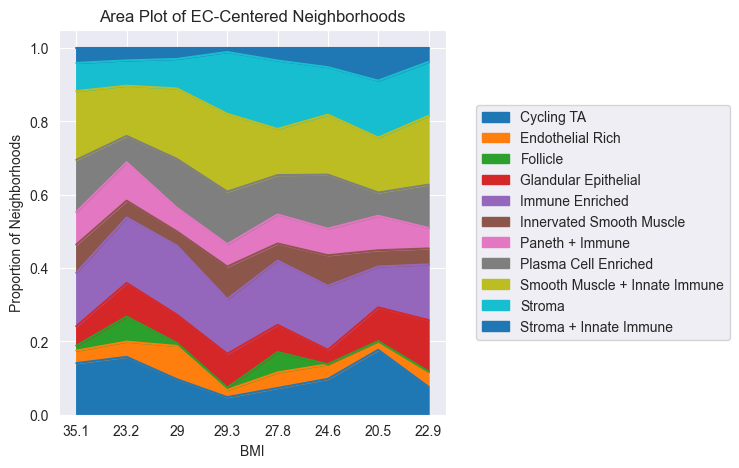

In [9]:
bmis = metadata['BMI'].sort_values()
view = area_pcts.join(bmis)
ax = view.plot.area(x='BMI', xlabel='BMI', ylabel='Proportion of Neighborhoods', 
                  title='Area Plot of EC-Centered Neighborhoods', figsize=[5,5])
ax.legend(loc='center right', bbox_to_anchor=(1.75, 0.5))

In [10]:
np.random.seed(0)
x = [float(i) for i in view['BMI']]
alpha = 0.05
lin_fits = {}
for col in ecn_list:
    y = [float(i) for i in area_pcts[col]]
    m, b, r, p, std_err = stats.linregress(x, y)
    lin_fits[col] = {'m':m,  'b':b, 'r':r, 'p':p, 'std_err':std_err}
lin_fits = pd.DataFrame(lin_fits).transpose()
lin_fits[lin_fits['p']<alpha]

,m,b,r,p,std_err


### Hypertension

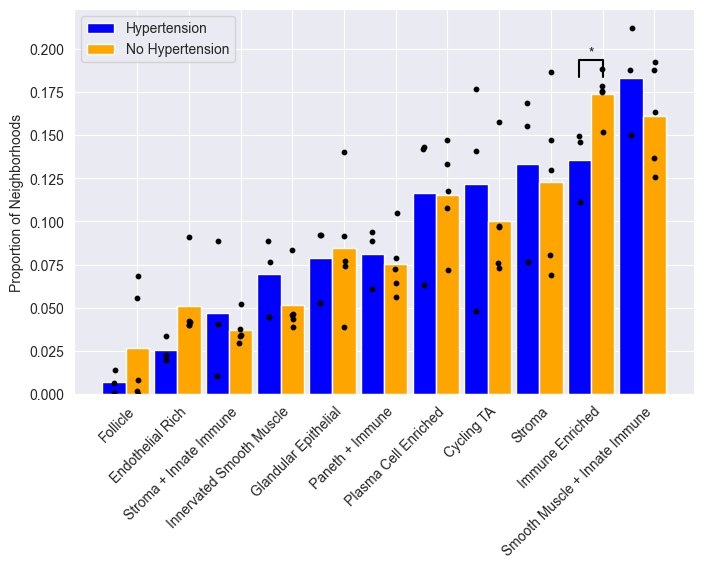

In [11]:
hypertension = area_pcts.loc[metadata['History of hypertension']]
no_hypertension = area_pcts.loc[~metadata['History of hypertension']]

hypertension_avgs = hypertension.mean()
no_hypertension_avgs = no_hypertension.mean()

hypertension_avgs = hypertension_avgs.sort_values(ascending=True)
no_hypertension_avgs = no_hypertension_avgs.reindex(hypertension_avgs.index)

x = np.arange(len(hypertension_avgs))
width=0.45

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, hypertension_avgs, width, label='Hypertension', color='blue')
ax.bar(x + width/2, no_hypertension_avgs, width, label='No Hypertension', color='orange')

def add_significance_star(x, y):
    x1 = x-width/2
    x2 = x+width/2
    plt.plot([x1, x1, x2, x2], [y+0.01, y+0.02, y+0.02, y+0.01], 'k-')
    plt.text((x1+x2)/2, y+0.02, '*', ha='center', va='bottom', fontsize=10)

hypertension_ttests = {}
for i, col in enumerate(hypertension_avgs.index):
    ax.scatter(np.random.normal(i - width/2, 0.01, hypertension[col].shape[0]), 
               hypertension[col], s=10, color='black')
    ax.scatter(np.random.normal(i + width/2, 0.01, no_hypertension[col].shape[0]), 
               no_hypertension[col], s=10, color='black')
    
    # independent t-test
    t_stat, p_value = stats.ttest_ind(hypertension[col], no_hypertension[col])
    hypertension_ttests[col] = {'t':t_stat, 'p':p_value}
    if p_value < alpha:
        add_significance_star(i, max(hypertension_avgs[col], no_hypertension_avgs[col]))

ax.set_xticks(x + width / 2)
ax.set_xticklabels(hypertension_avgs.index, rotation=45, ha='right')
ax.legend()
ax.set_ylabel('Proportion of Neighborhoods')
plt.show()

### Colon vs. Small Intestine

In [12]:
sb_data = cells[cells['tissue']=='SB'][keep_cols]
sb_data = sb_data[sb_data[ecn_col]!='Other']

cl_data = cells[cells['tissue']=='CL'][keep_cols]
cl_data = cl_data[cl_data[ecn_col]!='Other']

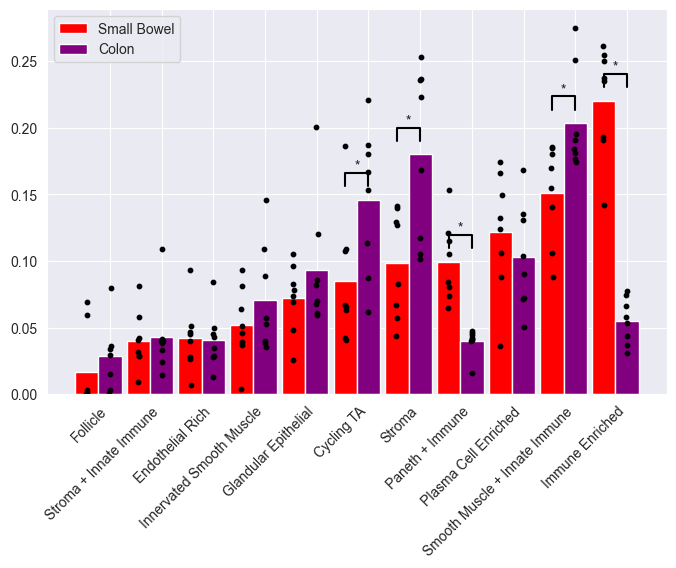

In [13]:
# Total Aggregate
sb_area_pcts = {}
for donor, data in sb_data.groupby('donor'):
    sb_area_pcts[donor] = data[ecn_col].value_counts()/len(data)
sb_area_pcts = pd.DataFrame(sb_area_pcts).transpose()

cl_area_pcts = {}
for donor, data in cl_data.groupby('donor'):
    cl_area_pcts[donor] = data[ecn_col].value_counts()/len(data)
cl_area_pcts = pd.DataFrame(cl_area_pcts).transpose()

sb_avgs = sb_area_pcts.mean()
cl_avgs = cl_area_pcts.mean()

sb_avgs = sb_avgs.sort_values(ascending=True)
cl_avgs = cl_avgs.reindex(sb_avgs.index)

x = np.arange(len(sb_avgs))
width=0.45

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, sb_avgs, width, label='Small Bowel', color='red')
ax.bar(x + width/2, cl_avgs, width, label='Colon', color='purple')

sb_cl_ttests = {}
for i, col in enumerate(sb_avgs.index):
    ax.scatter(np.random.normal(i - width/2, 0.01, sb_area_pcts[col].shape[0]), 
               sb_area_pcts[col], s=10, color='black')
    ax.scatter(np.random.normal(i + width/2, 0.01, cl_area_pcts[col].shape[0]), 
               cl_area_pcts[col], s=10, color='black')
    
    # paired t-test
    t_stat, p_value = stats.ttest_rel(sb_area_pcts[col], cl_area_pcts[col])     
    sb_cl_ttests[col] = {'t':t_stat, 'p':p_value}
    if p_value < alpha:
        add_significance_star(i, max(sb_avgs[col], cl_avgs[col]))

ax.set_xticks(x + width / 2)
ax.set_xticklabels(sb_avgs.index, rotation=45, ha='right')
ax.legend()
plt.show()